# Imports

In [1]:
import numpy as np
import pandas as pd

import sklearn as sk
from sklearn import base
from sklearn import calibration
from sklearn import cluster
from sklearn import compose
from sklearn import covariance
from sklearn import cross_decomposition
from sklearn import datasets
from sklearn import decomposition
from sklearn import discriminant_analysis
from sklearn import dummy
from sklearn import ensemble
from sklearn import exceptions
from sklearn import experimental
from sklearn import feature_extraction
from sklearn import feature_selection
from sklearn import gaussian_process
from sklearn import impute
from sklearn import inspection
from sklearn import isotonic
from sklearn import kernel_approximation
from sklearn import kernel_ridge
from sklearn import linear_model
from sklearn import manifold
from sklearn import metrics
from sklearn import mixture
from sklearn import model_selection
from sklearn import multiclass
from sklearn import multioutput
from sklearn import naive_bayes
from sklearn import neighbors
from sklearn import neural_network
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import random_projection
from sklearn import semi_supervised
from sklearn import svm
from sklearn import tree
from sklearn import utils

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Analisi

## Es. 1

In [2]:
df = pd.read_csv('dataset_modified.csv', sep=',')
df

,ID,year,Gender,approv_in_adv,loan_type,loan_purpose,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,occupancy_type,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Status
0,24890,2019,Sex Not Available,nopre,type1,p1,nopc,nob/c,116500,NaN,...,pr,1U,1740.0,EXP,758.0,CIB,25-34,to_inst,south,0
1,24891,2019,Male,nopre,type2,p1,nopc,b/c,206500,NaN,...,pr,1U,4980.0,EQUI,552.0,EXP,55-64,to_inst,North,1
2,24892,2019,Male,pre,type1,p1,nopc,nob/c,406500,4.560,...,pr,1U,9480.0,EXP,834.0,CIB,35-44,to_inst,south,1
3,24893,2019,Male,nopre,type1,p4,nopc,nob/c,456500,4.250,...,pr,1U,11880.0,EXP,587.0,CIB,45-54,not_inst,North,0
4,24894,2019,Joint,pre,type1,p1,nopc,nob/c,696500,4.000,...,pr,1U,10440.0,CRIF,602.0,EXP,25-34,not_inst,North,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21939,46829,2019,Sex Not Available,nopre,type1,p3,nopc,nob/c,146500,4.250,...,pr,1U,10260.0,CIB,723.0,EXP,>74,to_inst,south,1
21940,46830,2019,Male,pre,type2,p3,nopc,b/c,286500,3.990,...,pr,1U,8880.0,CRIF,616.0,EXP,35-44,to_inst,North,0
21941,46831,2019,Joint,nopre,type1,p4,nopc,nob/c,266500,3.625,...,pr,1U,6240.0,EXP,768.0,EXP,45-54,to_inst,south,1
21942,46832,2019,Female,nopre,type1,p4,nopc,nob/c,586500,NaN,...,pr,1U,10440.0,EQUI,503.0,EXP,35-44,not_inst,south,0


In [3]:
print('Rows (instances):', df.shape[0])

Rows (instances): 21944


In [4]:
df.isnull().sum()

ID                              0
year                            0
Gender                          0
approv_in_adv                 131
loan_type                       0
loan_purpose                   17
open_credit                     0
business_or_commercial          0
loan_amount                     0
rate_of_interest             5347
term                            9
lump_sum_payment                0
property_value               2242
construction_type               1
occupancy_type                  1
total_units                     1
income                       1318
credit_type                     1
Credit_Score                    1
co-applicant_credit_type        1
age                            27
submission_of_application      27
Region                          1
Status                          0
dtype: int64

Ci sono missing values per 15 feature.

In [5]:
df['Status'].value_counts()

Status
1    11014
0    10930
Name: count, dtype: int64

Dataset bilanciato rispetto al target.

## Es. 2

In [6]:
df['ratio'] = df['loan_amount']/df['property_value']
df

,ID,year,Gender,approv_in_adv,loan_type,loan_purpose,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Status,ratio
0,24890,2019,Sex Not Available,nopre,type1,p1,nopc,nob/c,116500,NaN,...,1U,1740.0,EXP,758.0,CIB,25-34,to_inst,south,0,0.987288
1,24891,2019,Male,nopre,type2,p1,nopc,b/c,206500,NaN,...,1U,4980.0,EQUI,552.0,EXP,55-64,to_inst,North,1,NaN
2,24892,2019,Male,pre,type1,p1,nopc,nob/c,406500,4.560,...,1U,9480.0,EXP,834.0,CIB,35-44,to_inst,south,1,0.800197
3,24893,2019,Male,nopre,type1,p4,nopc,nob/c,456500,4.250,...,1U,11880.0,EXP,587.0,CIB,45-54,not_inst,North,0,0.693769
4,24894,2019,Joint,pre,type1,p1,nopc,nob/c,696500,4.000,...,1U,10440.0,CRIF,602.0,EXP,25-34,not_inst,North,0,0.918865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21939,46829,2019,Sex Not Available,nopre,type1,p3,nopc,nob/c,146500,4.250,...,1U,10260.0,CIB,723.0,EXP,>74,to_inst,south,1,0.739899
21940,46830,2019,Male,pre,type2,p3,nopc,b/c,286500,3.990,...,1U,8880.0,CRIF,616.0,EXP,35-44,to_inst,North,0,0.847633
21941,46831,2019,Joint,nopre,type1,p4,nopc,nob/c,266500,3.625,...,1U,6240.0,EXP,768.0,EXP,45-54,to_inst,south,1,0.705026
21942,46832,2019,Female,nopre,type1,p4,nopc,nob/c,586500,NaN,...,1U,10440.0,EQUI,503.0,EXP,35-44,not_inst,south,0,NaN


In [7]:
group_mean = df['ratio'].groupby(df['total_units']).mean()
group_mean

total_units
1U    0.732230
2U    0.612850
3U    0.586999
4U    0.607033
Name: ratio, dtype: float64

In [8]:
type(group_mean)

pandas.core.series.Series

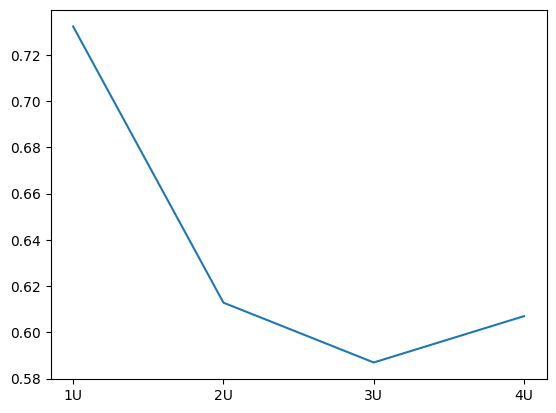

In [9]:
plt.plot(group_mean.index, group_mean.values)

No, al crescere del numero di unità non cresce il rapporto.

## Es. 3

In [10]:
df['age'].value_counts()

age
45-54    5194
35-44    4900
55-64    4797
65-74    2988
25-34    2775
>74      1081
<25       182
Name: count, dtype: int64

In [11]:
dfsenior = df[df['age'].isin(['55-64', '65-74', '>74'])].copy()
dfsenior['age'].value_counts()

age
55-64    4797
65-74    2988
>74      1081
Name: count, dtype: int64

In [12]:
dfsenior['income'] = pd.cut(dfsenior['income'], 5, labels=False)
dfsenior['Credit_Score'] = pd.cut(dfsenior['Credit_Score'], 5, labels=False)
dfsenior

,ID,year,Gender,approv_in_adv,loan_type,loan_purpose,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Status,ratio
1,24891,2019,Male,nopre,type2,p1,nopc,b/c,206500,NaN,...,1U,0.0,EQUI,0,EXP,55-64,to_inst,North,1,NaN
6,24896,2019,Joint,pre,type1,p3,nopc,nob/c,346500,4.500,...,1U,0.0,EXP,4,EXP,55-64,to_inst,North,1,0.791096
7,24897,2019,Female,nopre,type1,p4,nopc,nob/c,266500,4.125,...,1U,0.0,CIB,4,CIB,55-64,to_inst,North,1,0.865260
8,24898,2019,Joint,nopre,type1,p3,nopc,nob/c,376500,4.875,...,1U,0.0,CIB,0,EXP,55-64,to_inst,central,1,0.787657
9,24899,2019,Sex Not Available,nopre,type3,p3,nopc,nob/c,436500,3.490,...,1U,0.0,CIB,3,EXP,55-64,to_inst,south,0,0.634448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21928,46818,2019,Male,nopre,type1,p4,nopc,nob/c,326500,4.500,...,1U,0.0,EXP,3,EXP,>74,to_inst,south,1,0.712882
21930,46820,2019,Female,nopre,type1,p4,nopc,nob/c,186500,NaN,...,1U,0.0,EXP,3,CIB,55-64,to_inst,North,0,0.941919
21931,46821,2019,Joint,nopre,type1,p3,nopc,nob/c,486500,3.875,...,1U,0.0,CIB,3,EXP,>74,not_inst,North,0,0.567016
21932,46822,2019,Male,nopre,type1,p2,nopc,nob/c,136500,5.250,...,1U,0.0,CIB,0,EXP,55-64,to_inst,south,1,0.429245


In [13]:
piv_t = dfsenior.pivot_table(values='Status', index='income', columns='Credit_Score', aggfunc='mean', dropna=True)
piv_t

Credit_Score,0,1,2,3,4
income,,,,,
0.0,0.493961,0.502497,0.480712,0.518094,0.472716
1.0,0.555556,0.300000,0.600000,0.375000,0.555556
2.0,1.000000,NaN,0.500000,0.400000,0.500000
4.0,NaN,0.000000,NaN,0.000000,NaN


## Es. 4

In [14]:
df_primarie = df[df['occupancy_type'] == 'pr'].copy()
df_primarie

,ID,year,Gender,approv_in_adv,loan_type,loan_purpose,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Status,ratio
0,24890,2019,Sex Not Available,nopre,type1,p1,nopc,nob/c,116500,NaN,...,1U,1740.0,EXP,758.0,CIB,25-34,to_inst,south,0,0.987288
1,24891,2019,Male,nopre,type2,p1,nopc,b/c,206500,NaN,...,1U,4980.0,EQUI,552.0,EXP,55-64,to_inst,North,1,NaN
2,24892,2019,Male,pre,type1,p1,nopc,nob/c,406500,4.560,...,1U,9480.0,EXP,834.0,CIB,35-44,to_inst,south,1,0.800197
3,24893,2019,Male,nopre,type1,p4,nopc,nob/c,456500,4.250,...,1U,11880.0,EXP,587.0,CIB,45-54,not_inst,North,0,0.693769
4,24894,2019,Joint,pre,type1,p1,nopc,nob/c,696500,4.000,...,1U,10440.0,CRIF,602.0,EXP,25-34,not_inst,North,0,0.918865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21938,46828,2019,Sex Not Available,nopre,type1,p4,nopc,nob/c,616500,NaN,...,1U,8340.0,CIB,851.0,CIB,35-44,not_inst,south,0,0.835366
21939,46829,2019,Sex Not Available,nopre,type1,p3,nopc,nob/c,146500,4.250,...,1U,10260.0,CIB,723.0,EXP,>74,to_inst,south,1,0.739899
21940,46830,2019,Male,pre,type2,p3,nopc,b/c,286500,3.990,...,1U,8880.0,CRIF,616.0,EXP,35-44,to_inst,North,0,0.847633
21941,46831,2019,Joint,nopre,type1,p4,nopc,nob/c,266500,3.625,...,1U,6240.0,EXP,768.0,EXP,45-54,to_inst,south,1,0.705026


Text(0, 0.5, 'property_value')

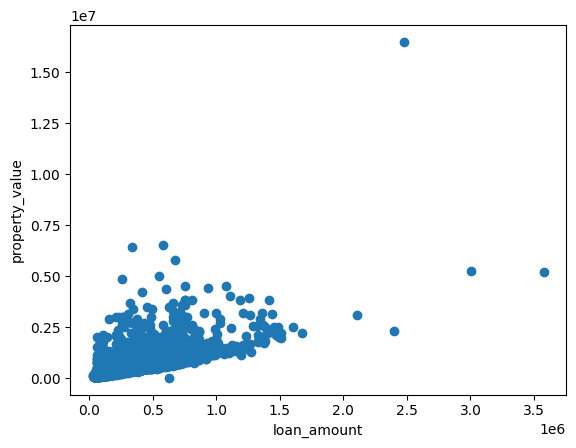

In [15]:
plt.scatter(df_primarie['loan_amount'], df_primarie['property_value'])
plt.xlabel('loan_amount')
plt.ylabel('property_value')

# Trasformazione e Predizione

## Es. 1

In [16]:
df = pd.read_csv('dataset_modified.csv', sep=',')
df = df.drop('ID', axis=1) # per evitare l'overfitting
df = df.dropna()
df

,year,Gender,approv_in_adv,loan_type,loan_purpose,open_credit,business_or_commercial,loan_amount,rate_of_interest,term,...,occupancy_type,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Status
2,2019,Male,pre,type1,p1,nopc,nob/c,406500,4.560,360.0,...,pr,1U,9480.0,EXP,834.0,CIB,35-44,to_inst,south,1
3,2019,Male,nopre,type1,p4,nopc,nob/c,456500,4.250,360.0,...,pr,1U,11880.0,EXP,587.0,CIB,45-54,not_inst,North,0
4,2019,Joint,pre,type1,p1,nopc,nob/c,696500,4.000,360.0,...,pr,1U,10440.0,CRIF,602.0,EXP,25-34,not_inst,North,0
5,2019,Joint,pre,type1,p1,nopc,nob/c,706500,3.990,360.0,...,pr,1U,10080.0,EXP,864.0,EXP,35-44,not_inst,North,1
6,2019,Joint,pre,type1,p3,nopc,nob/c,346500,4.500,360.0,...,pr,1U,5040.0,EXP,860.0,EXP,55-64,to_inst,North,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21935,2019,Male,pre,type1,p4,nopc,nob/c,596500,4.125,360.0,...,pr,2U,8580.0,CRIF,839.0,CIB,35-44,not_inst,south,1
21937,2019,Male,nopre,type1,p4,nopc,nob/c,656500,3.750,360.0,...,pr,1U,9180.0,CIB,527.0,CIB,45-54,not_inst,south,1
21939,2019,Sex Not Available,nopre,type1,p3,nopc,nob/c,146500,4.250,180.0,...,pr,1U,10260.0,CIB,723.0,EXP,>74,to_inst,south,1
21940,2019,Male,pre,type2,p3,nopc,b/c,286500,3.990,360.0,...,pr,1U,8880.0,CRIF,616.0,EXP,35-44,to_inst,North,0


In [17]:
categorical_cols = [cname for cname in df.columns if df[cname].dtype == "object"]
enc = preprocessing.OrdinalEncoder()
df[categorical_cols] = enc.fit_transform(df[categorical_cols])
df

,year,Gender,approv_in_adv,loan_type,loan_purpose,open_credit,business_or_commercial,loan_amount,rate_of_interest,term,...,occupancy_type,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Status
2,2019,2.0,1.0,0.0,0.0,0.0,1.0,406500,4.560,360.0,...,1.0,0.0,9480.0,2.0,834.0,0.0,1.0,1.0,3.0,1
3,2019,2.0,0.0,0.0,3.0,0.0,1.0,456500,4.250,360.0,...,1.0,0.0,11880.0,2.0,587.0,0.0,2.0,0.0,0.0,0
4,2019,1.0,1.0,0.0,0.0,0.0,1.0,696500,4.000,360.0,...,1.0,0.0,10440.0,1.0,602.0,1.0,0.0,0.0,0.0,0
5,2019,1.0,1.0,0.0,0.0,0.0,1.0,706500,3.990,360.0,...,1.0,0.0,10080.0,2.0,864.0,1.0,1.0,0.0,0.0,1
6,2019,1.0,1.0,0.0,2.0,0.0,1.0,346500,4.500,360.0,...,1.0,0.0,5040.0,2.0,860.0,1.0,3.0,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21935,2019,2.0,1.0,0.0,3.0,0.0,1.0,596500,4.125,360.0,...,1.0,1.0,8580.0,1.0,839.0,0.0,1.0,0.0,3.0,1
21937,2019,2.0,0.0,0.0,3.0,0.0,1.0,656500,3.750,360.0,...,1.0,0.0,9180.0,0.0,527.0,0.0,2.0,0.0,3.0,1
21939,2019,3.0,0.0,0.0,2.0,0.0,1.0,146500,4.250,180.0,...,1.0,0.0,10260.0,0.0,723.0,1.0,6.0,1.0,3.0,1
21940,2019,2.0,1.0,1.0,2.0,0.0,0.0,286500,3.990,360.0,...,1.0,0.0,8880.0,1.0,616.0,1.0,1.0,1.0,0.0,0


In [18]:
X = df.drop('Status', axis=1)
y = df['Status']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, stratify=y)

In [19]:
def evaluate_model(model):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print(model)
    print("F1 Score train:", metrics.f1_score(y_train, y_train_pred))
    print("F1 Score test:", metrics.f1_score(y_test, y_test_pred))
    print('Confusion matrix train\n', metrics.confusion_matrix(y_train, y_train_pred))
    print('Confusion matrix test\n', metrics.confusion_matrix(y_test, y_test_pred))
    print()

evaluate_model(tree.ExtraTreeClassifier())
evaluate_model(neighbors.KNeighborsClassifier())
evaluate_model(dummy.DummyClassifier(strategy='stratified'))


ExtraTreeClassifier()
F1 Score train: 1.0
F1 Score test: 0.5042318543216209
Confusion matrix train
 [[5763    0]
 [   0 5736]]
Confusion matrix test
 [[ 918 1004]
 [ 929  983]]

KNeighborsClassifier()
F1 Score train: 0.6801399825021872
F1 Score test: 0.4946695095948827
Confusion matrix train
 [[3956 1807]
 [1849 3887]]
Confusion matrix test
 [[1010  912]
 [ 984  928]]

DummyClassifier(strategy='stratified')
F1 Score train: 0.49386583137561996
F1 Score test: 0.49001331557922767
Confusion matrix train
 [[2844 2919]
 [2898 2838]]
Confusion matrix test
 [[999 923]
 [992 920]]



I due classificatori non performano meglio di un dummy estimator.

## Es. 2

In [20]:
scores_tree = model_selection.cross_val_score(tree.ExtraTreeClassifier(), X, y, scoring='f1', cv=10, n_jobs=-1)
scores_kneighbors = model_selection.cross_val_score(neighbors.KNeighborsClassifier(), X, y, scoring='f1', cv=10, n_jobs=-1)

print(f'F1 Score: {scores_tree.mean()*100}%')
print(f'F1 Score: {scores_kneighbors.mean()*100}%')

F1 Score: 48.74372402575021%
F1 Score: 49.419286470590066%


## Es. 3

In [21]:
enc.categories_

[array(['Female', 'Joint', 'Male', 'Sex Not Available'], dtype=object),
 array(['nopre', 'pre'], dtype=object),
 array(['type1', 'type2', 'type3'], dtype=object),
 array(['p1', 'p2', 'p3', 'p4'], dtype=object),
 array(['nopc', 'opc'], dtype=object),
 array(['b/c', 'nob/c'], dtype=object),
 array(['lpsm', 'not_lpsm'], dtype=object),
 array(['sb'], dtype=object),
 array(['ir', 'pr', 'sr'], dtype=object),
 array(['1U', '2U', '3U', '4U'], dtype=object),
 array(['CIB', 'CRIF', 'EXP'], dtype=object),
 array(['CIB', 'EXP'], dtype=object),
 array(['25-34', '35-44', '45-54', '55-64', '65-74', '<25', '>74'],
       dtype=object),
 array(['not_inst', 'to_inst'], dtype=object),
 array(['North', 'North-East', 'central', 'south'], dtype=object)]

In [22]:
tree_clf = tree.ExtraTreeClassifier()
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
kn = neighbors.KNeighborsClassifier()
kn.fit(X_train, y_train)
y_pred_kn = kn.predict(X_test)

X_test['pred_tree'] = y_pred_tree
X_test['pred_kn'] = y_pred_kn

men = X_test[X_test['Gender'] == 2]
women = X_test[X_test['Gender'] == 0]

prob_man_tree = men[men['pred_tree']==1].shape[0] / men.shape[0]
prob_man_kn = men[men['pred_kn']==1].shape[0] / men.shape[0]
prob_woman_tree = women[women['pred_tree']==1].shape[0] / women.shape[0]
prob_woman_kn = women[women['pred_kn']==1].shape[0] / women.shape[0]

print('Probabilità uomo tree: {}'.format(prob_man_tree))
print('Probabilità uomo kn: {}'.format(prob_man_kn))
print('Probabilità donna tree: {}'.format(prob_woman_tree))
print('Probabilità donna kn: {}'.format(prob_woman_kn))

Probabilità uomo tree: 0.5046816479400749
Probabilità uomo kn: 0.4953183520599251
Probabilità donna tree: 0.5049365303244006
Probabilità donna kn: 0.4992947813822285


Il tree predice più stati di inadempimento per le donne piuttosto che per gli uomini.
Per il kn la predizione può essere considerata abbastanza simile.

## Es. 4

In [23]:
correlation_matrix = df.corr()
top2_pos = correlation_matrix['Status'].sort_values(ascending=False).iloc[1:3].index.tolist()
top2_neg = correlation_matrix['Status'].sort_values(ascending=True).iloc[1:3].index.tolist()
print(top2_pos)
print(top2_neg)

['loan_type', 'open_credit']
['business_or_commercial', 'loan_amount']


In [24]:
df2 = df[[*top2_neg, *top2_pos, 'Status']].copy()
df2

,business_or_commercial,loan_amount,loan_type,open_credit,Status
2,1.0,406500,0.0,0.0,1
3,1.0,456500,0.0,0.0,0
4,1.0,696500,0.0,0.0,0
5,1.0,706500,0.0,0.0,1
6,1.0,346500,0.0,0.0,1
...,...,...,...,...,...
21935,1.0,596500,0.0,0.0,1
21937,1.0,656500,0.0,0.0,1
21939,1.0,146500,0.0,0.0,1
21940,0.0,286500,1.0,0.0,0


In [25]:
X = df2.drop('Status', axis=1)
y = df2['Status']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, stratify=y)

tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)

print("F1 Score:", metrics.f1_score(y_test, y_pred))

F1 Score: 0.47624309392265196


## Es. 5

In [26]:
X = df.drop('Status', axis=1)
y = df['Status']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, stratify=y)

In [27]:
parameters = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [5, 10, 20, None]
}

gridsearch = model_selection.GridSearchCV(tree_clf, parameters, scoring='f1')

gridsearch.fit(X_train, y_train)

print('Best params:', gridsearch.best_params_)
print('Best estimator:', gridsearch.best_estimator_)
print('Best score:', gridsearch.best_score_)

Best params: {'criterion': 'log_loss', 'max_depth': None}
Best estimator: ExtraTreeClassifier(criterion='log_loss')
Best score: 0.5065350452017515


## Es. 6

In [28]:
preprocessor = compose.ColumnTransformer(transformers=[('discr', preprocessing.KBinsDiscretizer(n_bins=7), ['income', 'loan_amount']),
                                                  ('std', preprocessing.StandardScaler(), ['Credit_Score'])],
                                    remainder='passthrough')

model = tree.ExtraTreeClassifier(random_state=0)

my_pipeline = pipeline.Pipeline(steps=[('preprocessor', preprocessor),
                                    ('model', model)])

my_pipeline.fit(X=X_train, y=y_train)

y_pred = my_pipeline.predict(X=X_test)
print("F1 Score:", metrics.f1_score(y_test, y_pred))

F1 Score: 0.4986972381448671


## Es. 7

In [29]:
my_pipeline2 = pipeline.Pipeline(steps=[('preprocessor', preprocessor),
                                       ('SVD', decomposition.TruncatedSVD()),
                                        ('model', model)])

params = {
    "SVD__n_components": [2, 4, 6],
    "model__criterion": ['gini', 'entropy', 'log_loss'],
    "model__max_depth": [5, 10, 20, None]
}

gridsearch = model_selection.GridSearchCV(my_pipeline2, params, scoring='f1')

gridsearch.fit(X_train, y_train)

print('Best params:', gridsearch.best_params_)
print('Best estimator:', gridsearch.best_estimator_)
print('Best score:', gridsearch.best_score_)

Best params: {'SVD__n_components': 4, 'model__criterion': 'entropy', 'model__max_depth': None}
Best estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('discr',
                                                  KBinsDiscretizer(n_bins=7),
                                                  ['income', 'loan_amount']),
                                                 ('std', StandardScaler(),
                                                  ['Credit_Score'])])),
                ('SVD', TruncatedSVD(n_components=4)),
                ('model',
                 ExtraTreeClassifier(criterion='entropy', random_state=0))])
Best score: 0.5068071296767181
